In [1]:
#Here I try to fit my Decision Tree to training data
from sourceCode.decisionTree.decisiontree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor as DT
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np

In [2]:
df = pd.read_csv(r"data\claims_train_final.csv")
df.drop("Area",axis=1,inplace=True)

In [3]:
fuel_map = {'Regular': 0, 'Diesel': 1}

df['VehGas'] = df['VehGas'].map(fuel_map)

In [4]:
#df_dummy = pd.get_dummies(df,columns=["VehBrand"],dtype=int)

In [5]:
#df = df_dummy
#df

In [4]:
x = df.drop(columns=["ClaimNb","Region","VehBrand"])
y = df["ClaimNb"]


In [5]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [6]:
dt = DecisionTreeRegressor(max_depth=9,max_leaf_nodes=29,min_samples_split=100,rss_loss=False)
dt.fit(x_train,y_train)


Splitting 1223 items on BonusMalus at 66.5. RSS Improvement: 592.409887330954
Splitting 1276 items on Density at 30.5. RSS Improvement: 598.2547765157017
Splitting 1015 items on DrivAge at 30.5. RSS Improvement: 624.4556034179985
Splitting 309 items on Density at 8239.0. RSS Improvement: 135.28766574946187
Splitting 1324 items on DrivAge at 48.5. RSS Improvement: 769.6367979967664
Splitting 2600 items on Exposure at 0.08499999999999999. RSS Improvement: 1387.3340062968828
Splitting 100 items on DrivAge at 64.5. RSS Improvement: 17.79698841219468
Splitting 148 items on Density at 59.5. RSS Improvement: 60.93632155959483
Splitting 842 items on Density at 4706.0. RSS Improvement: 264.85565535232644
Splitting 899 items on Density at 126.5. RSS Improvement: 268.05771963523716
Splitting 1047 items on Density at 86.5. RSS Improvement: 345.26943631751186
Splitting 3647 items on DrivAge at 56.5. RSS Improvement: 1751.197044362215
Splitting 1013 items on Density at 819.0. RSS Improvement: 758.02

In [9]:
max(df["Density"])

27000

In [7]:
prediction = dt.predict(x_test)

In [9]:
dt_sk = DT(max_depth=9,max_leaf_nodes=29,min_samples_split=30)
dt_sk.fit(x_train,y_train)

prediction_sk = dt_sk.predict(x_test)

In [10]:
import numpy as np
def r_squared(model,truth):
    predictions_np = np.array(model)
    true_label_np = np.array(truth)
    TSS = np.sum((true_label_np - np.mean(true_label_np))**2)
    RSS = np.sum((predictions_np - true_label_np)**2)
    return (TSS - RSS)/TSS

r2_score(y_test,prediction_sk)
#r2_score(y_train,prediction_s)


0.024952428078546363

In [13]:
x = x.values


In [14]:
splits = np.unique(np.percentile(x[:, 4], np.linspace(0, 100, 100)))
splits

array([ 50.,  51.,  52.,  54.,  56.,  57.,  59.,  60.,  61.,  62.,  64.,
        67.,  68.,  69.,  72.,  76.,  80.,  85.,  88.,  90.,  95.,  98.,
       100., 106., 158.])

In [15]:
splits = np.unique(x[:, 4])
splits

array([ 50.,  51.,  52.,  53.,  54.,  55.,  56.,  57.,  58.,  59.,  60.,
        61.,  62.,  63.,  64.,  65.,  66.,  67.,  68.,  69.,  70.,  71.,
        72.,  73.,  74.,  75.,  76.,  77.,  78.,  79.,  80.,  81.,  82.,
        83.,  84.,  85.,  86.,  87.,  88.,  89.,  90.,  91.,  92.,  93.,
        94.,  95.,  96.,  97.,  98.,  99., 100., 101., 102., 103., 104.,
       105., 106., 107., 108., 109., 110., 111., 112., 113., 114., 115.,
       116., 117., 118., 119., 120., 121., 122., 123., 124., 125., 126.,
       128., 130., 132., 133., 135., 136., 138., 139., 140., 141., 142.,
       144., 147., 148., 149., 151., 156., 158.])

In [16]:
from sklearn.tree import DecisionTreeRegressor as SK
dt_sk = SK()
dt_sk.fit(x_train,y_train)
prediction = dt_sk.predict(x_test)

In [17]:
r_squared(prediction,y_test)

np.float64(-1.158857927183703)

In [18]:
import numpy as np
def rss(data_points):
        """ For a given list of data points in a region, 
            this function returns the residual sum of squares for that region"""
        mean = np.mean(data_points)
        RSS = np.sum((data_points - mean)**2) #For each region our prediction is the mean of points in that R
        return RSS

rss(x["BonusMalus"])

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [1]:
from sourceCode.decisionTree.decisiontree import DecisionTreeRegressor as DecesionTree_scratch
from sklearn.tree import DecisionTreeRegressor
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

def run_DT(training_data:pd.DataFrame,scratch=True):
    if scratch == True:
        dt = DecesionTree_scratch(max_depth=5,min_sample_split=100,rss_loss=True)
    else: 
        dt = DecisionTreeRegressor()

    Y = training_data["ClaimNb"]
    X = training_data.drop(columns="ClaimNb")
    X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
    dt.fit(X_train,Y_train)
    predictions = dt.predict(X_test)
    return predictions, Y_test

def r_squared(predictions,true_label):
    predictions_np = np.array(predictions)
    true_label_np = np.array(true_label)
    TSS = np.sum((true_label_np - np.mean(true_label_np))**2)
    RSS = np.sum((predictions_np - true_label_np)**2)
    return (TSS - RSS)/TSS

def cross_validation():
    pass



In [56]:
x = x.to_numpy()
y = y.to_numpy()
dt = DecisionTreeRegressor(max_depth=4)
dt.fit(x,y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [32]:
from sklearn.metrics import r2_score
df = pd.read_csv(r"data\claims_train_scaled.csv")
x = df.drop(columns=["ClaimNb","VehGas","VehBrand","Region","Area"])
y = df["ClaimNb"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
dt = SK(max_depth=5,max_leaf_nodes=20)
dt.fit(x_train,y_train)
prediction = dt.predict(x_test)
print(r_squared(prediction, y_test))
r2_score(y_test,prediction)

0.019674129206013927


0.01967412920601397

In [13]:
from sklearn.tree import DecisionTreeRegressor as SK
from sklearn.model_selection import KFold
df = pd.read_csv(r"data\claims_train_scaled.csv")

df = df.drop(columns=["VehGas","VehBrand","Region","Area"])
for j in range(10,100,5):
    kf = KFold(n_splits=5)
    R_Vals_sklearn = []
    print(f"Max Depth = {j}")
    for i, (train_index, test_index) in enumerate(kf.split(df)):
        #print(f"Fold {i}:")
        df_train = df.iloc[train_index]
        df_test = df.iloc[test_index]
        dt = SK(min_samples_split=j)
        dt.fit(df_train.drop("ClaimNb",axis=1),df_train["ClaimNb"])
        predictions = dt.predict(df_test.drop("ClaimNb",axis=1))
        r = r_squared(predictions,df_test["ClaimNb"])
        R_Vals_sklearn.append(r)
    print(f"For max samples = {j} the average R Squared Value is {np.mean(R_Vals_sklearn)}")
        

Max Depth = 10
For max samples = 10 the average R Squared Value is -0.5147707171872978
Max Depth = 15
For max samples = 15 the average R Squared Value is -0.37640390726119516
Max Depth = 20
For max samples = 20 the average R Squared Value is -0.30083484158876705
Max Depth = 25
For max samples = 25 the average R Squared Value is -0.2517256073572138
Max Depth = 30
For max samples = 30 the average R Squared Value is -0.21703590051373153
Max Depth = 35
For max samples = 35 the average R Squared Value is -0.19099719650543348
Max Depth = 40
For max samples = 40 the average R Squared Value is -0.17041534849703685
Max Depth = 45
For max samples = 45 the average R Squared Value is -0.15242870026868546
Max Depth = 50
For max samples = 50 the average R Squared Value is -0.13781559719106526
Max Depth = 55
For max samples = 55 the average R Squared Value is -0.1253622269199405
Max Depth = 60
For max samples = 60 the average R Squared Value is -0.1145909495606009
Max Depth = 65
For max samples = 65 

In [21]:
R_Vals_sklearn

[np.float64(0.01708454006548034),
 np.float64(0.019721219856935385),
 np.float64(0.02003099696308602),
 np.float64(0.017947846640722277),
 np.float64(0.01998720634454142)]

In [11]:
#using pca scores to fit DT
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
df = pd.read_csv(r"data\claims_train_scaled.csv")
df_new = df.drop(columns=["VehGas","VehBrand","Region","Area","ClaimNb"])
pca_claims = PCA()
pca_claims.fit(df_new)
scores = pca_claims.transform(df_new)
df_pca = pd.DataFrame(scores)


Text(0, 0.5, 'Cummalative Sum of Explained Variance')

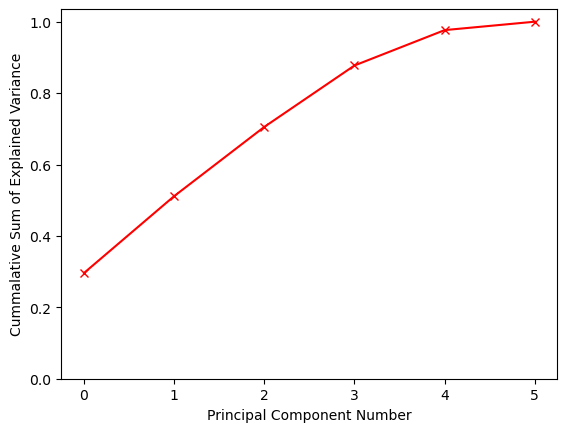

In [80]:
#explained variance
explained_var = pca_claims.explained_variance_ratio_
cum_sum = np.cumsum(explained_var)
plt.plot(range(len(cum_sum)),cum_sum,marker="x",c="red")
plt.ylim(0)
plt.xlabel("Principal Component Number")
plt.ylabel("Cummalative Sum of Explained Variance")


In [27]:
for j in range(2,32,5):
    kf = KFold(n_splits=5)
    Avg_r_vals = {i:0 for i in range(j)}
    print(f"Max Depth = {j}")
    for i, (train_index, test_index) in enumerate(kf.split(df_pca)):
        R_Vals_sklearn = []
        #print(f"Fold {i}:")
        df_train = df_pca.iloc[train_index]
        df_target_train = df.iloc[train_index]
        df_test = df_pca.iloc[test_index]
        df_target_test = df.iloc[test_index]
        dt = SK(max_leaf_nodes=j)
        dt.fit(df_train,df_target_train["ClaimNb"])
        predictions = dt.predict(df_test)
        r = r_squared(predictions,df_target_test["ClaimNb"])
        R_Vals_sklearn.append(r)
    print(f"For max samples = {j} the average R Squared Value is {np.mean(R_Vals_sklearn)}")
    Avg_r_vals[j] = np.mean(R_Vals_sklearn) 

print(Avg_r_vals)

Max Depth = 2
For max samples = 2 the average R Squared Value is 0.004655326983205001
Max Depth = 7
For max samples = 7 the average R Squared Value is 0.012476897376257927
Max Depth = 12
For max samples = 12 the average R Squared Value is 0.014297619706104776
Max Depth = 17
For max samples = 17 the average R Squared Value is 0.015558176081808425
Max Depth = 22
For max samples = 22 the average R Squared Value is 0.016252195308454558
Max Depth = 27
For max samples = 27 the average R Squared Value is 0.01587552127672919
{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 0, 26: 0, 27: np.float64(0.01587552127672919)}


Text(0.5, 1.0, 'Averge R-Squared using KFold vs Max Leaf Nodes')

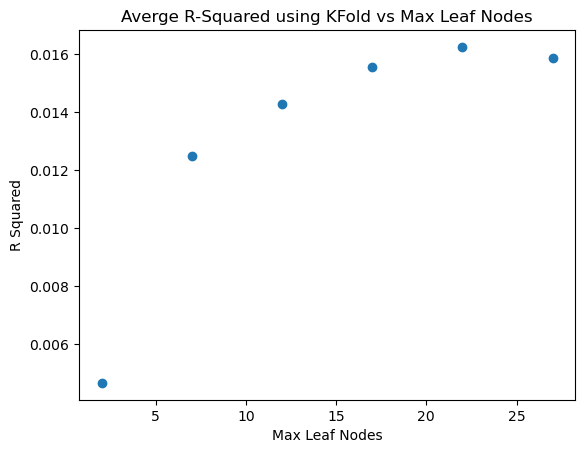

In [34]:
vals = {2:0.004655326983205001,7:0.012476897376257927,12:0.014297619706104776,17:0.015558176081808425,22:0.016252195308454558,27:0.01587552127672919}
plt.scatter(vals.keys(),vals.values())
plt.xlabel("Max Leaf Nodes")
plt.ylabel("R Squared")
plt.title("Averge R-Squared using KFold vs Max Leaf Nodes")

Text(0, 0.5, 'R Squared')

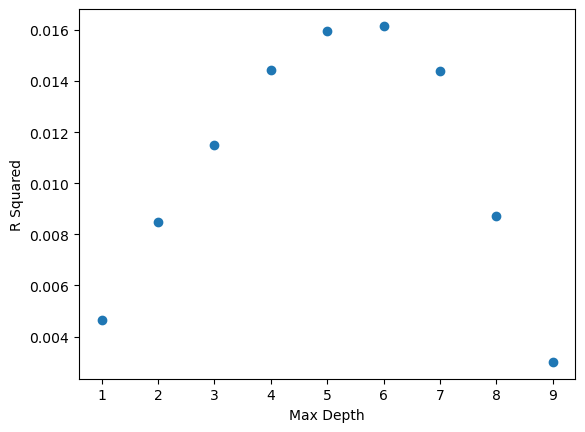

In [24]:
vals = {1:0.004655326983205001,2:0.008488118515138279,3:0.011488323019566857,4:0.014442610435605572,5:0.01594074183634016,6:0.016155793723355107,7:0.014384521083490382,8:0.008713323261855822,9:0.0030099698534020837}
plt.scatter(vals.keys(),vals.values())
plt.xlabel("Max Depth")
plt.ylabel("R Squared")
plt.title("Averge R-Squared using KFold vs Max Depth")

In [3]:
#RandomSearch 
from sklearn.model_selection import RandomizedSearchCV

param_dict = {
    'max_depth': [int(x) for x in range(1,10)],
    'max_leaf_nodes' : [int(x) for x in range(1,30,2)],
    'min_samples_split' : [int(x) for x in range(10,120,10)]
}

dt_classifier = DecisionTreeRegressor()

random_search = RandomizedSearchCV(
    estimator=dt_classifier,
    param_distributions=param_dict,
    n_iter=100,  # Number of parameter settings that are sampled
    cv=5,  # Number of cross-validation folds
    verbose=2,
    scoring="r2",
    random_state=42,
    n_jobs=-1  # Use all available processors
)


In [4]:
df = pd.read_csv(r"data\claims_train_final.csv")
df.drop("Area",axis=1,inplace=True)

fuel_map = {'Regular': 0, 'Diesel': 1}

df['VehGas'] = df['VehGas'].map(fuel_map)

x = df.drop(columns=["ClaimNb","Region","VehBrand"])
y = df["ClaimNb"]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
random_search.fit(x_train,y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


KeyboardInterrupt: 

In [36]:
# Retrieve the best parameters found by RandomizedSearchCV
best_params = random_search.best_params_
print("Best Parameters:", best_params)

# Evaluate the model with best parameters on the test set
best_estimator = random_search.best_estimator_
test_accuracy = best_estimator.score(x_test, y_test)
print("Test r2 with Best Parameters:", test_accuracy)

Best Parameters: {'min_samples_split': 30, 'max_leaf_nodes': 29, 'max_depth': 9}
Test r2 with Best Parameters: 0.024952428078546363
